In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/11"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第11章 構造化分布 (Structured Distributions)
## 11.3 系列モデル (Sequence Models)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第11章「構造化分布」第11.3節「系列モデル (Sequence Models)」および11.3.1節「状態空間モデル (State-Space Models)」の理論解説、数学的定式化、教科書図版（Figure 11.27 〜 11.31 全5枚）の完全再現、共通モジュール実装、および数値シミュレーション・検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **系列データの確率的定式化と自己回帰モデル (図 11.27)**
   - 一般の自己回帰結合：$p(x_1, \dots, x_N) = \prod_{n=1}^N p(x_n \mid x_1, \dots, x_{n-1})$
   - 完全結合有向非巡回グラフ（DAG）としての表現
3. **独立系列モデルとマルコフ連鎖 (図 11.28 〜 11.30)**
   - 独立系列モデル：$p(\mathbf{x}) = \prod_n p(x_n)$ (図 11.28)
   - 第1次マルコフ連鎖 (First-Order Markov Chain, 図 11.29)：$p(x_n \mid x_1, \dots, x_{n-1}) = p(x_n \mid x_{n-1})$
   - 第2次マルコフ連鎖 (Second-Order Markov Chain, 図 11.30)：$p(x_n \mid x_1, \dots, x_{n-1}) = p(x_n \mid x_{n-1}, x_{n-2})$
   - 高次マルコフモデルのパラメータ爆発問題 ($K^{M+1}$)
4. **11.3.1 状態空間モデル (State-Space Models) & 隠れマルコフモデル (HMM, 図 11.31)**
   - 潜在状態列 $\mathbf{z}$ による第1次マルコフ連鎖と観測 $\mathbf{x}$ の条件付き独立放出
   - 同時確率分布：$p(\mathbf{x}, \mathbf{z}) = p(z_1) p(x_1 \mid z_1) \prod_{n=2}^N p(z_n \mid z_{n-1}) p(x_n \mid z_n)$
   - D分離に基づく重要な性質：
     - $z_n$ を観測すると $x_n$ は他の全変数から孤立 ($x_n \perp \mathbf{x}_{\setminus n}, \mathbf{z}_{\setminus n} \mid z_n$)
     - 潜在状態 $\mathbf{z}$ を周辺化（未観測）すると、任意の観測対 $(x_i, x_j)$ 間が潜在連鎖を通じてすべて非遮断となり、パラメータ数を抑制したまま無限の有効記憶・長距離依存性を実現！
5. **推論アルゴリズムの実装と数値検証**
   - 前向きアルゴリズム (Forward Algorithm) による周辺尤度 $p(\mathbf{x})$ の動的計画法計算
   - ビタビアルゴリズム (Viterbi Algorithm) による最尤潜在系列 $\mathbf{z}^*$ の大域的復号
   - マルコフ連鎖の定常分布 (Stationary Distribution) 収束シミュレーション
6. **まとめと第12章（トランスフォーマー / 注意機構）への架け橋**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "11" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.graphical_models import DirectedGraph
from common.conditional_independence import check_d_separation
from common.sequence_models import (
    MarkovChainSimulator,
    HiddenMarkovModel,
    generate_figure_11_27,
    generate_figure_11_28,
    generate_figure_11_29,
    generate_figure_11_30,
    generate_figure_11_31,
)

setup_style()
print("Setup complete. Common sequence models ready.")


Setup complete. Common sequence models ready.


## 1. 一般の自己回帰モデル (Autoregressive Models)

時系列データ、音声波形、自然言語の単語列など、順序を持つ系列データ $\mathbf{x} = (x_1, x_2, \dots, x_N)$ の同時確率分布を考えます。
確率の乗法定理（連鎖律）を用いると、任意の分布は仮定なしに次のように厳密に因数分解されます：

$$
p(x_1, x_2, \dots, x_N) = \prod_{n=1}^N p(x_n \mid x_1, \dots, x_{n-1})
$$

これをグラフィカルモデルとして表現すると、先行するすべてのノード $x_1, \dots, x_{n-1}$ から現時点のノード $x_n$ へ有向エッジが伸びる **完全結合 DAG (Fully Connected DAG)** となります（**図 11.27**）。
これは深層自己回帰モデル（WaveNet, PixelCNN, GPT等のデコーダモデル）の理論的基盤です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_27.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_27.png


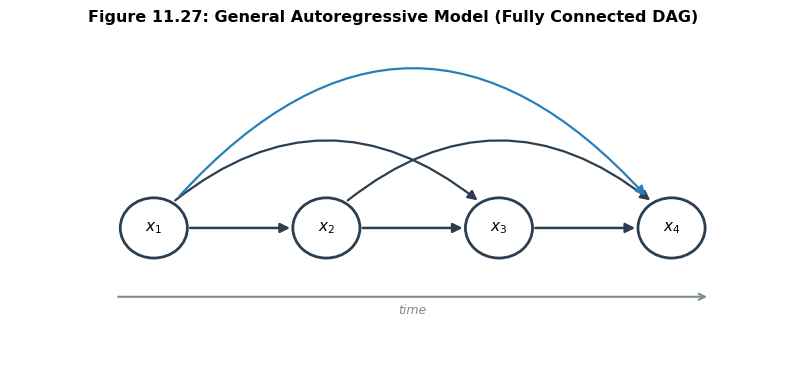

In [2]:
fig = generate_figure_11_27()
plt.show()


## 2. 独立系列モデルとマルコフ連鎖

### 2.1 独立系列モデル (Independent Sequence Model, 図 11.28)
最も極端な単純化は、すべての時点の観測が無相関・独立であるという仮定です：
$$
p(\mathbf{x}) = \prod_{n=1}^N p(x_n)
$$
このモデルではグラフにエッジが存在せず、過去の履歴は将来の予測に一切役立ちません。

### 2.2 第1次マルコフ連鎖 (First-Order Markov Chain, 図 11.29)
「現時点の観測 $x_n$ の条件付き分布は、直前の観測 $x_{n-1}$ のみに依存し、それ以前の過去 $x_1, \dots, x_{n-2}$ とは条件付き独立である」というマルコフ仮定（Markov Assumption）を置きます：
$$
p(x_n \mid x_1, \dots, x_{n-1}) = p(x_n \mid x_{n-1})
$$
同時分布は次のように大幅に因数分解されます：
$$
p(x_1, \dots, x_N) = p(x_1) \prod_{n=2}^N p(x_n \mid x_{n-1})
$$
D分離基準を適用すると、パス $x_1 - x_2 - \dots - x_n$ において $x_{n-1}$ はヘッド・トゥ・テール（head-to-tail）ノードであるため、$x_{n-1}$ を観測（条件付け）することで過去と未来が完全に遮断（d-分離）されます：
$$
x_n \perp x_1, \dots, x_{n-2} \mid x_{n-1}
$$

### 2.3 第2次マルコフ連鎖 (Second-Order Markov Chain, 図 11.30)
直前2ステップの履歴に依存するモデルです：
$$
p(x_n \mid x_1, \dots, x_{n-1}) = p(x_n \mid x_{n-1}, x_{n-2})
$$
同時分布：
$$
p(x_1, \dots, x_N) = p(x_1) p(x_2 \mid x_1) \prod_{n=3}^N p(x_n \mid x_{n-1}, x_{n-2})
$$
一般に $M$ 次マルコフ連鎖では $M$ 個の先行ステップに依存しますが、離散状態数 $K$ のとき条件付き確率表のパラメータ数は $O(K^{M+1})$ と指数関数的に爆発し、長期記憶を持たせることは実質的に不可能です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_28.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_28.png


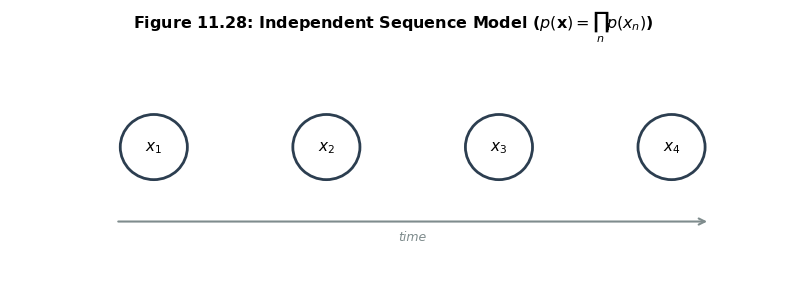

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_29.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_29.png


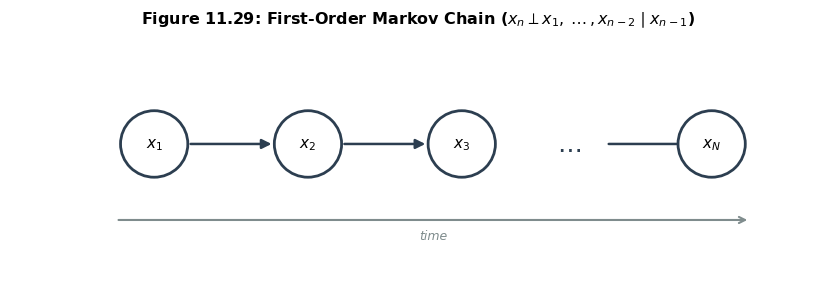

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_30.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_30.png


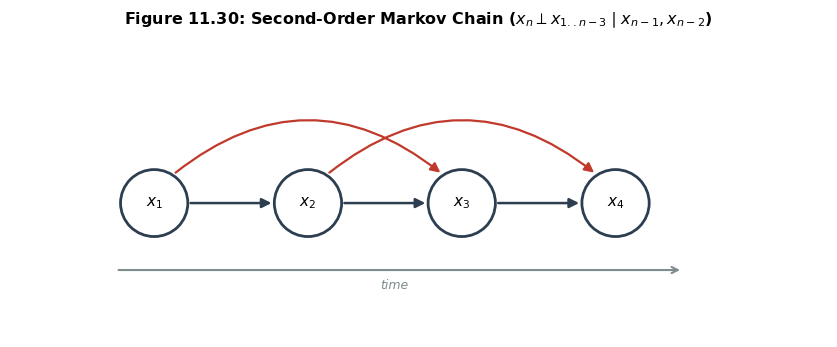

In [3]:
fig_28 = generate_figure_11_28()
plt.show()

fig_29 = generate_figure_11_29()
plt.show()

fig_30 = generate_figure_11_30()
plt.show()


## 3. 状態空間モデル (State-Space Models) & 隠れマルコフモデル (HMM)

高次マルコフ連鎖のパラメータ爆発問題をエレガントに解決するのが **状態空間モデル (State-Space Models, SSM)** です（**図 11.31**）。

### 3.1 構造と因数分解
- 直接観測されない潜在変数列 $\mathbf{z} = (z_1, \dots, z_N)$ を導入し、潜在変数自身は第1次マルコフ連鎖を形成させます。
- 各時点の観測 $x_n$ は、同じ時点の潜在状態 $z_n$ のみに依存して生成（放出）されます。
- 同時確率分布：
$$
p(\mathbf{x}, \mathbf{z}) = p(z_1) p(x_1 \mid z_1) \prod_{n=2}^N p(z_n \mid z_{n-1}) p(x_n \mid z_n)
$$

### 3.2 D分離から得られる驚異的な性質
1. **局所的条件付き独立性**:
   潜在状態 $z_n$ が与えられたとき、観測 $x_n$ はグラフ内の他のすべての変数と独立になります：
   $$
   x_n \perp \mathbf{x}_{\setminus n}, \mathbf{z}_{\setminus n} \mid z_n
   $$
2. **大域的長距離相関（無限記憶）**:
   潜在変数 $\mathbf{z}$ は実際には観測されないため、観測変数 $\mathbf{x}$ の周辺分布 $p(\mathbf{x}) = \sum_{\mathbf{z}} p(\mathbf{x}, \mathbf{z})$ を考えると、潜在ノード群はすべて未観測となります。
   任意の2点 $x_i$ と $x_j$ を結ぶパス：
   $$
   x_i \leftarrow z_i \to z_{i+1} \to \dots \to z_j \to x_j
   $$
   にはコライダー（collider, head-to-head）が1つも存在しません！
   したがって、潜在変数が未観測である限り、このパスは**一切遮断されず常に導通**します。
   すなわち、**「任意の観測 $x_i$ と $x_j$ は周辺従属であり、系列全体の長距離依存性をコンパクトなパラメータ数 $O(K^2)$ で完全にモデル化できる」** という極めて強力な表現力を獲得します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_31.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_31.png


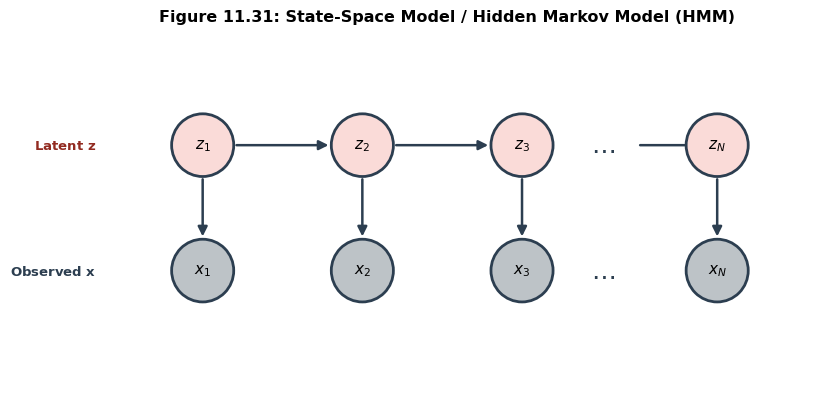

In [4]:
fig_31 = generate_figure_11_31()
plt.show()


## 4. 推論アルゴリズムの実装と数値シミュレーション

### 4.1 前向きアルゴリズム (Forward Algorithm)
観測系列 $\mathbf{x}_{1:N}$ の周辺尤度 $p(\mathbf{x})$ を計算するため、動的計画法による前向きメッセージ $\alpha_n(j) = p(x_1, \dots, x_n, z_n = j)$ を再帰的に計算します：
$$
\alpha_1(j) = \pi_j p(x_1 \mid z_1 = j)
$$
$$
\alpha_n(j) = \left[ \sum_{i=1}^K \alpha_{n-1}(i) A_{ij} \right] p(x_n \mid z_n = j)
$$
周辺尤度は最終ステップの和で求まります：
$$
p(\mathbf{x}) = \sum_{j=1}^K \alpha_N(j)
$$

### 4.2 ビタビアルゴリズム (Viterbi Algorithm)
最も確からしい潜在状態系列 $\mathbf{z}^* = \arg\max_{\mathbf{z}} p(\mathbf{z}, \mathbf{x})$ を max-product アルゴリズムで探索します。


In [5]:
# 1. マルコフ連鎖シミュレーションと定常分布
T = np.array([
    [0.85, 0.15],
    [0.30, 0.70]
])
pi0 = np.array([1.0, 0.0])
mc = MarkovChainSimulator(T, pi0)
seq = mc.sample_sequence(1000, seed=42)
stat_dist = mc.compute_stationary_distribution()
emp_dist = np.bincount(seq, minlength=2) / len(seq)

print("=== マルコフ連鎖の定常分布検証 ===")
print(f"理論的定常分布: pi = {stat_dist}")
print(f"サンプリング経験分布: pi_emp = {emp_dist}")

# 2. 隠れマルコフモデル (HMM) による前向き尤度計算 & ビタビ最尤系列復号
A = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
])
B = np.array([
    [0.1, 0.4, 0.5],
    [0.6, 0.3, 0.1]
])
pi = np.array([0.6, 0.4])
hmm = HiddenMarkovModel(A, B, pi)

obs = np.array([0, 1, 2, 0, 1, 2])
likelihood, alpha = hmm.forward_algorithm(obs)
best_path = hmm.viterbi_algorithm(obs)

print("\n=== 隠れマルコフモデルの推論結果 ===")
print(f"観測系列: {obs}")
print(f"前向きアルゴリズムによる周辺尤度 p(x): {likelihood:.6e}")
print(f"ビタビアルゴリズムによる最尤潜在系列 z*: {best_path}")

# 3. D分離によるグラフィカルモデル特性の厳密検証
dag_ssm = DirectedGraph(["z1", "z2", "z3", "x1", "x2", "x3"])
dag_ssm.add_edge("z1", "z2")
dag_ssm.add_edge("z2", "z3")
dag_ssm.add_edge("z1", "x1")
dag_ssm.add_edge("z2", "x2")
dag_ssm.add_edge("z3", "x3")

# x1 と x3 は潜在変数が与えられていないとき従属（長距離依存）
indep_unobs = check_d_separation(dag_ssm, {"x1"}, {"x3"}, set())
# x1 と x3 は z1, z2 が与えられると条件付き独立
indep_obs = check_d_separation(dag_ssm, {"x1"}, {"x3"}, {"z1", "z2"})

print("\n=== 状態空間モデルのD分離検証 ===")
print(f"未観測時: x1 _|_ x3 | phi -> {indep_unobs} (False: 導通・長距離相関が存在)")
print(f"潜在状態観測時: x1 _|_ x3 | {{z1, z2}} -> {indep_obs} (True: 遮断・独立)")


=== マルコフ連鎖の定常分布検証 ===
理論的定常分布: pi = [0.66666667 0.33333333]
サンプリング経験分布: pi_emp = [0.646 0.354]

=== 隠れマルコフモデルの推論結果 ===
観測系列: [0 1 2 0 1 2]
前向きアルゴリズムによる周辺尤度 p(x): 1.027143e-03
ビタビアルゴリズムによる最尤潜在系列 z*: [1 0 0 1 0 0]

=== 状態空間モデルのD分離検証 ===
未観測時: x1 _|_ x3 | phi -> False (False: 導通・長距離相関が存在)
潜在状態観測時: x1 _|_ x3 | {z1, z2} -> True (True: 遮断・独立)


## 5. まとめと第12章トランスフォーマーへの展開

### 本節の要点
1. **自己回帰モデル**:
   - 確率の乗法定理により先行する全変数に依存する完全結合DAG。表現力は無限だが系列長 $N$ に対し計算量が $O(N^2)$ に増加。
2. **マルコフ連鎖**:
   - 直前 $M$ ステップのみへの依存を仮定。パラメータ数を抑えられるが、有効記憶長が $M$ に制限され、長距離依存性を捉えられない。
3. **状態空間モデル (SSM / HMM)**:
   - 観測されない潜在変数にマルコフ構造を持たせることで、潜在ノードを周辺化した観測空間において**全観測間の大域的長距離依存性**をコンパクトなパラメータ数で達成。

### 次章：第12章 トランスフォーマー (Transformers) への架け橋
状態空間モデルや再帰型ニューラルネットワーク（RNN）は時間ステップに沿った逐次的計算を必要とするため、GPUによる並列計算が困難でした。
次章 **第12章 トランスフォーマー (Transformers)** では、自己注意機構（Self-Attention）を導入することで、任意のトークン間を直接 $O(1)$ のパスで結び、完全な並列学習と強力な文脈モデル化を両立する現代深層学習の最重要アーキテクチャを探究します。
